# Approach 1 — guided design with the dual surrogate + oracle

Property-guided FP design wired to the models from `surrogate_model_design_dual.ipynb`:

- **Surrogate** = `dual_surrogate_net.pt` (**cnn-max**) — *guides* refinement.
- **Oracle** = `dual_oracle_net.pt` (**cnn-max**, trained on the oracle split) — independent *evaluator*.

Both are CNNs trained with a **cosine-similarity** loss; each predicts **PCA coefficients** that are reconstructed
and **peak-normalized** to a spectrum via its saved PCA basis. Guided generation scores candidates by **cosine
similarity** to the target spectrum (not MSE). Using the dual labels (`dual_splits.csv`) we design toward
**in-sample** (surrogate-seen) and **OOD** (surrogate-unseen) targets, judged by the oracle, sweeping the guidance
strength **λ ∈ {5, 15}**.

## 0. Setup + data + dual labels

In [1]:
import csv, os, numpy as np, torch, joblib
import arcadia_pycolor as apc, fp_models as fpm
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True; apc.mpl.setup()
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32); grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EMM=np.array([float(r["em_max"]) for r in rows]); EXM=np.array([float(r["ex_max"]) for r in rows])
seqs=[None]*N; h=None
for line in open(os.path.join(TD,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
dual=list(csv.DictReader(open(os.path.join(TD,"dual_splits.csv"))))
Srole=np.array([d["surrogate_role"] for d in dual]); Orole=np.array([d["oracle_role"] for d in dual])
print("device",dev,"| N",N,"| surrogate roles",{b:int((Srole==b).sum()) for b in('train','val','test')})

device mps | N 453 | surrogate roles {'train': 317, 'val': 68, 'test': 68}


## 1. Load dual models (+ PCA bases) and wire spectrum predictors

In [2]:
surrogate_net, s_meta = fpm.load_model(os.path.join("trained_models","dual_surrogate_net.pt"), dev)
oracle_net,    o_meta = fpm.load_model(os.path.join("trained_models","dual_oracle_net.pt"), dev)
surr_pca = joblib.load(os.path.join("trained_models","dual_surrogate_pca.joblib"))
orac_pca = joblib.load(os.path.join("trained_models","dual_oracle_pca.joblib"))
print(f"surrogate: {s_meta['sid']} (out={s_meta['out']} PCA coeffs) | val MSE {s_meta['metrics']['val']['mse']:.4f}")
print(f"oracle:    {o_meta['sid']} (out={o_meta['out']} PCA coeffs) | val MSE {o_meta['metrics']['val']['mse']:.4f}")

g_spectrum      = fpm.pca_spectrum_fn(surrogate_net, surr_pca, dev)   # GUIDANCE (PCA recon + peak-normalized spectrum)
oracle_spectrum = fpm.pca_spectrum_fn(oracle_net,   orac_pca, dev)    # EVALUATION (PCA recon + peak-normalized spectrum)

esm_model, alphabet, bc = fpm.get_esm(dev)
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

surrogate: cnn-max (out=32 PCA coeffs) | val MSE 0.0326
oracle:    cnn-max (out=32 PCA coeffs) | val MSE 0.0325


## 2. Pseudo-perplexity (naturalness)

In [3]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    _,_,base=bc([("s",seq.strip().upper())]); base=base[0].to(dev)
    res=[i for i,t in enumerate(base.tolist()) if t not in SPECIAL]; tot=0.0
    for s in range(0,len(res),batch_size):
        ch=res[s:s+batch_size]; bt=base.unsqueeze(0).repeat(len(ch),1).clone()
        for r,p in enumerate(ch): bt[r,p]=alphabet.mask_idx
        lp=torch.log_softmax(esm_model(bt)["logits"],dim=-1)
        for r,p in enumerate(ch): tot+=float(lp[r,p,base[p]])
    n=len(res); return tot, float(np.exp(-tot/n))

loaded cached pseudo-perplexities (fp_designs/ppl_id_ood.csv)
ID  median 15.90 (n=40) | OOD median 15.67 (n=40) | Mann-Whitney p=0.37


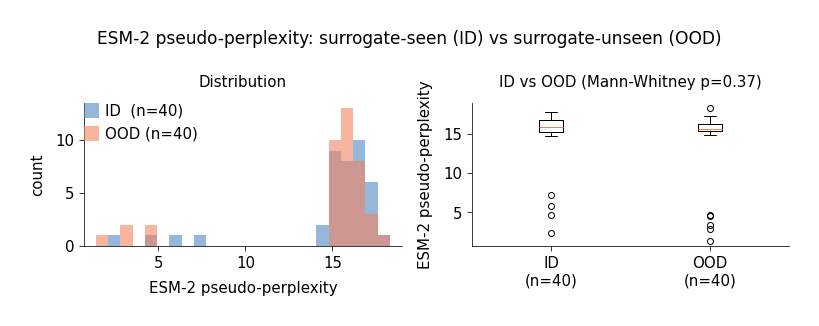

In [4]:
# Pseudo-perplexity distribution: ID (surrogate-seen, Srole==train) vs OOD (surrogate-unseen, Srole==test)
from scipy.stats import mannwhitneyu
PPL_PER_GROUP=40          # sample size per group (None = all; all is slow); results cached to fp_designs/
ppl_cache=os.path.join("fp_designs","ppl_id_ood.csv")
if os.path.exists(ppl_cache):
    rec=list(csv.DictReader(open(ppl_cache)))
    groups={g:np.array([float(r["ppl"]) for r in rec if r["group"]==g]) for g in ("ID","OOD")}
    print(f"loaded cached pseudo-perplexities ({ppl_cache})")
else:
    rng_ppl=np.random.default_rng(0)
    def _sample(role):
        idx=np.where(Srole==role)[0]
        if PPL_PER_GROUP and len(idx)>PPL_PER_GROUP: idx=np.sort(rng_ppl.choice(idx,PPL_PER_GROUP,replace=False))
        return idx
    groups={}; out_rows=[]
    for g,role in [("ID","train"),("OOD","test")]:
        vals=[]
        for i in _sample(role):
            _,p=pseudo_perplexity(seqs[i]); vals.append(p); out_rows.append((g,int(i),rows[i]["name"],f"{p:.4f}"))
        groups[g]=np.array(vals); print(f"{g}: n={len(vals)} median {np.median(vals):.2f} mean {np.mean(vals):.2f}")
    os.makedirs("fp_designs",exist_ok=True)
    with open(ppl_cache,"w",newline="") as fh:
        w=csv.writer(fh); w.writerow(["group","idx","name","ppl"]); [w.writerow(r) for r in out_rows]
    print(f"saved -> {ppl_cache}")

p_mwu=mannwhitneyu(groups["OOD"],groups["ID"],alternative="two-sided").pvalue
print(f"ID  median {np.median(groups['ID']):.2f} (n={len(groups['ID'])}) | "
      f"OOD median {np.median(groups['OOD']):.2f} (n={len(groups['OOD'])}) | Mann-Whitney p={p_mwu:.2g}")
if HAVE_PLT:
    fig,ax=plt.subplots(1,2,figsize=(11,4))
    lo=min(groups['ID'].min(),groups['OOD'].min()); hi=max(groups['ID'].max(),groups['OOD'].max())
    bins=np.linspace(lo,hi,25)
    ax[0].hist(groups['ID'], bins=bins, alpha=0.6, color=apc.aegean, label=f"ID  (n={len(groups['ID'])})")
    ax[0].hist(groups['OOD'],bins=bins, alpha=0.6, color=apc.amber,  label=f"OOD (n={len(groups['OOD'])})")
    ax[0].set_xlabel("ESM-2 pseudo-perplexity"); ax[0].set_ylabel("count"); ax[0].legend(); ax[0].set_title("Distribution")
    ax[1].boxplot([groups['ID'],groups['OOD']], tick_labels=[f"ID\n(n={len(groups['ID'])})", f"OOD\n(n={len(groups['OOD'])})"])
    ax[1].set_ylabel("ESM-2 pseudo-perplexity"); ax[1].set_title(f"ID vs OOD (Mann-Whitney p={p_mwu:.2g})")
    plt.suptitle("ESM-2 pseudo-perplexity: surrogate-seen (ID) vs surrogate-unseen (OOD)")
    plt.tight_layout(); plt.show()

## 3. Guided refinement (surrogate guides, oracle evaluates)

In [5]:
def to_tokens(seq): _,_,t=bc([("q",seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d): return "".join(alphabet.get_tok(int(x)) for x in t1d if int(x) not in SPECIAL)

def cos_sim_vec(P, t):
    """Mean per-half (ex|em) cosine similarity between spectra P (B,2G) and a target t (2G,). Higher = better."""
    def cs(a,b): return (a*b).sum(-1)/(a.norm(dim=-1)*b.norm(dim=-1)+1e-8)
    return 0.5*(cs(P[:,:G], t[:G]) + cs(P[:,G:], t[G:]))

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam=5.0, temperature=0.0, editable=None, eval_fn=None, verbose=True):
    toks=to_tokens(seq)
    res=[i for i,t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res=[res[j] for j in editable]
    trace=[]
    for sweep in range(n_sweeps):
        for pos in res:
            toks[0,pos]=alphabet.mask_idx
            lg=esm_model(toks)["logits"][0,pos].masked_fill(~AA_MASK,float("-inf"))
            logp=torch.log_softmax(lg,-1); topv,topi=torch.topk(logp,k)
            cand=[]
            for idx in topi.tolist(): toks[0,pos]=idx; cand.append(tokens_to_seq(toks[0]))
            sim=cos_sim_vec(g_spectrum(cand), target)                              # surrogate guidance: cosine similarity
            lpz=(topv-topv.mean())/(topv.std()+1e-6); sz=(sim-sim.mean())/(sim.std()+1e-6)
            scores=lpz+lam*sz                                                       # reward naturalness + spectral similarity
            ch=(torch.multinomial(torch.softmax(scores/temperature,-1),1).item() if temperature>0 else int(torch.argmax(scores)))
            toks[0,pos]=int(topi[ch].item())
        cur=tokens_to_seq(toks[0])
        ev=(eval_fn(cur)[0] if eval_fn is not None else g_spectrum(cur)[0])         # oracle evaluation
        sim_ev=float(cos_sim_vec(ev.unsqueeze(0), target)[0]); trace.append(sim_ev)
        if verbose: print(f"  sweep {sweep}: oracle cosine {sim_ev:.4f}")
    return tokens_to_seq(toks[0]), trace

## 4. Train/train examples — sequence-similar, spectrally-distinct pairs

We test guided design on pairs where **both models trained on both endpoints** (`Srole==train` **and** `Orole==train`), so the oracle baseline and the surrogate guidance are both in-distribution. For each example we auto-pick a scaffold→target pair that is **highly similar in sequence** (top 4-mer similarity, identity ≤ `IDENT_MAX`) yet **spectrally distinct** (emission gap ≥ `EM_GAP_MIN` nm); scaffold = bluer member, target = redder. We take `N_EXAMPLES` distinct pairs (no sequence reused).

**Design process (identical generation logic to before):** ESM-2 masked-LM windowed refinement over a `WINDOW`-residue window, one sweep per round, continuing from the previous round; candidates scored by `naturalness + λ·cosine(surrogate spectrum, target)`. **Schedule:** start at **λ=20** and **ramp +3 each round for 10 rounds** (λ = 20, 23, …, 47). Each example is saved to its own `fp_designs/design_<scaffold>-<target>.csv` (round-0 row = scaffold).

In [6]:
REGENERATE=True       # set False to reuse existing fp_designs/design_*.csv
LAM_START=20; LAM_STEP=3; N_ROUNDS=10; WINDOW=40; K_TOP=6
EM_GAP_MIN=20; EM_GAP_MAX=80; IDENT_MAX=0.98; N_EXAMPLES=3
desdir="fp_designs"; os.makedirs(desdir, exist_ok=True)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as _cossim
import biotite.sequence as _bseq, biotite.sequence.align as _balign
_MAT=_balign.SubstitutionMatrix.std_protein_matrix()
def seq_identity(a,b):
    aln=_balign.align_optimal(_bseq.ProteinSequence(a),_bseq.ProteinSequence(b),_MAT,gap_penalty=(-10,-1))[0]
    return float(_balign.get_sequence_identity(aln))
def sanitize(s): return "".join(ch if (ch.isalnum() or ch in "-_.") else "_" for ch in s)
def find_pairs(role,n):                                            # top-n 4-mer-similar pairs: spectrally distinct, not duplicates, no seq reused
    idx=np.where((Srole==role)&(Orole=="train"))[0]      # train/train only: both surrogate AND oracle trained on these
    X=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform([seqs[i] for i in idx])
    S=_cossim(X)
    cand=[(float(S[a,b]),int(idx[a]),int(idx[b])) for a in range(len(idx)) for b in range(a+1,len(idx))
          if EM_GAP_MIN<=abs(EMM[idx[a]]-EMM[idx[b]])<=EM_GAP_MAX]
    cand.sort(reverse=True)
    pairs=[]; used=set()
    for _,i,j in cand:
        if i in used or j in used: continue
        if seqs[i]==seqs[j] or seq_identity(seqs[i],seqs[j])>IDENT_MAX: continue
        pairs.append((i,j) if EMM[i]<=EMM[j] else (j,i)); used.update([i,j])   # scaffold=bluer, target=redder
        if len(pairs)>=n: break
    return pairs

if REGENERATE:
    pairs=find_pairs("train", N_EXAMPLES)
    schedule=[(r, LAM_START+LAM_STEP*(r-1)) for r in range(1,N_ROUNDS+1)]
    saved=[]
    for si,ti in pairs:
        scaffold=seqs[si]; t=torch.tensor(Y[ti],device=dev); Llen=len(scaffold); mid=Llen//2
        editable=list(range(max(0,mid-WINDOW//2),min(Llen,mid+WINDOW//2)))
        name=f"{rows[si]['name']}-{rows[ti]['name']}"; idn=seq_identity(scaffold,seqs[ti])
        print(f"[{name}] scaffold em{EMM[si]:.0f} -> target em{EMM[ti]:.0f} | seq id {idn:.0%} | window {WINDOW} | \u03bb {LAM_START}->{LAM_START+LAM_STEP*(N_ROUNDS-1)} (+{LAM_STEP}/round)")
        hist=[dict(lam_used=LAM_START,round=0,cos=float(cos_sim_vec(oracle_spectrum(scaffold),t)[0]),ppl=pseudo_perplexity(scaffold)[1],ident=1.0,seq=scaffold)]
        cur=scaffold
        for r,lam_used in schedule:
            cur,_=guided_refine(cur,t,n_sweeps=1,k=K_TOP,lam=lam_used,editable=editable,eval_fn=oracle_spectrum,verbose=False)
            cr=float(cos_sim_vec(oracle_spectrum(cur),t)[0]); pr=pseudo_perplexity(cur)[1]
            idr=sum(x==y for x,y in zip(cur,scaffold))/len(scaffold)
            hist.append(dict(lam_used=lam_used,round=r,cos=cr,ppl=pr,ident=idr,seq=cur))
            print(f"  round {r:>2} (\u03bb={lam_used}): cos {cr:.3f} | ppl {pr:.1f} | id {idr:.2f}")
        fn=os.path.join(desdir, f"design_{sanitize(name)}.csv")
        with open(fn,"w",newline="") as fh:
            w=csv.writer(fh)
            w.writerow(["example","lam_used","round","scaffold_name","scaffold_idx","scaffold_em","target_name","target_idx","target_em","seq_id_scaf_target","cos","ppl","ident_to_scaffold","designed_seq","scaffold_seq","target_seq"])
            for h in hist:
                w.writerow([name,h["lam_used"],h["round"],rows[si]["name"],si,f"{EMM[si]:.0f}",rows[ti]["name"],ti,f"{EMM[ti]:.0f}",f"{idn:.3f}",f"{h['cos']:.4f}",f"{h['ppl']:.2f}",f"{h['ident']:.3f}",h["seq"],scaffold,seqs[ti]])
        saved.append(fn); print(f"  saved -> {fn}")
    print("saved examples:", [os.path.basename(s) for s in saved])
else:
    import glob; print("REGENERATE=False -> reuse:", [os.path.basename(f) for f in sorted(glob.glob(os.path.join(desdir,"design_*.csv")))])

[Cerulean-WasCFP] scaffold em475 -> target em505 | seq id 98% | window 40 | λ 20->47 (+3/round)


  round  1 (λ=20): cos 0.771 | ppl 15.2 | id 0.88


  round  2 (λ=23): cos 0.798 | ppl 15.4 | id 0.87


  round  3 (λ=26): cos 0.782 | ppl 16.0 | id 0.87


  round  4 (λ=29): cos 0.780 | ppl 15.6 | id 0.86


...

  round  6 (λ=35): cos 0.519 | ppl 13.6 | id 0.88


  round  7 (λ=38): cos 0.450 | ppl 13.6 | id 0.86


  round  8 (λ=41): cos 0.422 | ppl 14.0 | id 0.86


  round  9 (λ=44): cos 0.471 | ppl 13.5 | id 0.86


  round 10 (λ=47): cos 0.443 | ppl 13.6 | id 0.86
  saved -> fp_designs/design_mHoneydew-mRFP1.csv
saved examples: ['design_Cerulean-WasCFP.csv', 'design_EGFP-Citrine.csv', 'design_mHoneydew-mRFP1.csv']


## 5. Design cycles — cosine, perplexity, spectra (per example)

For each example: (1) oracle **cosine vs round**, (2) ESM-2 **pseudo-perplexity vs round**, and (3) the design **excitation / emission** spectra converging to the target, colored **light→dark** with round (round 0 = **scaffold**, green; rose = target). Same visualization style as before.

3 example(s): ['design_Cerulean-WasCFP.csv', 'design_EGFP-Citrine.csv', 'design_mHoneydew-mRFP1.csv']
--- Cerulean-WasCFP: Cerulean (em475) -> WasCFP (em505) | seq id 98% | cos 0.67 -> 0.78


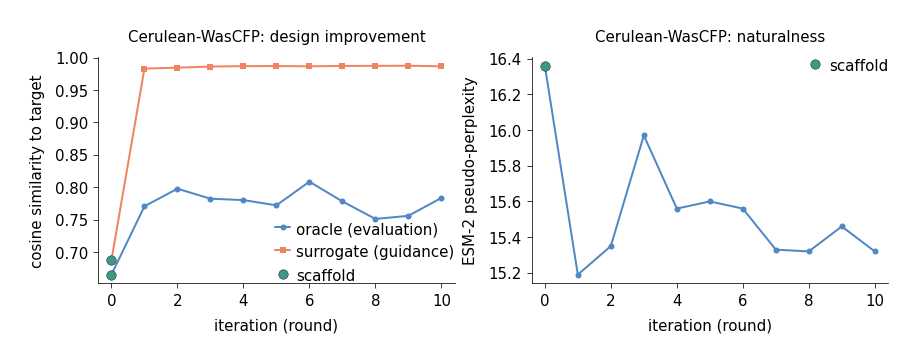

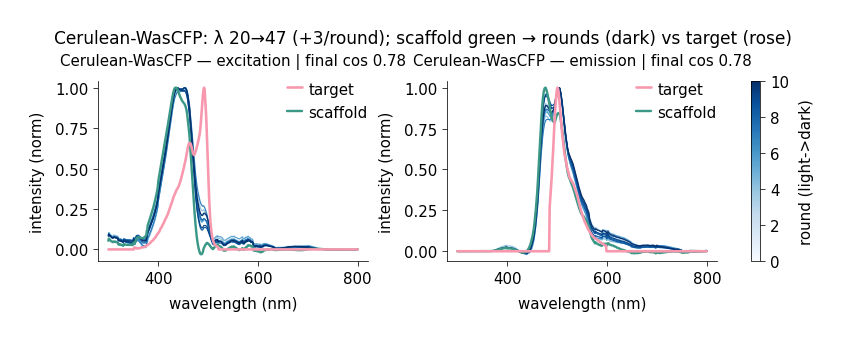

--- EGFP-Citrine: EGFP (em507) -> Citrine (em529) | seq id 98% | cos 0.59 -> 0.62


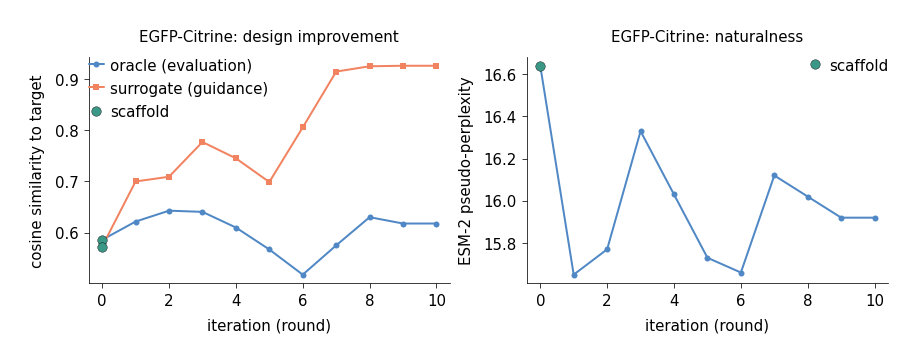

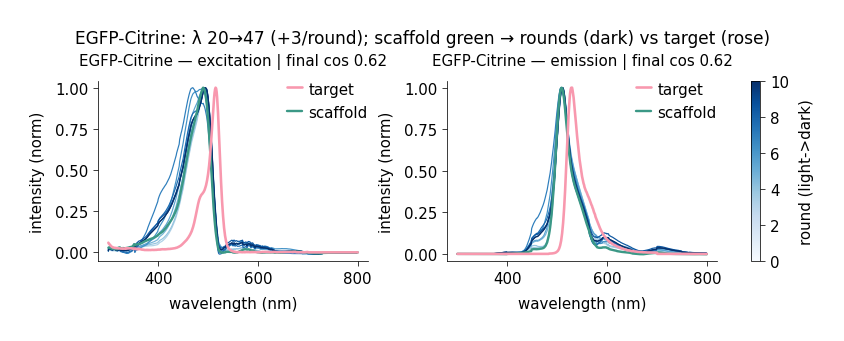

--- mHoneydew-mRFP1: mHoneydew (em562) -> mRFP1 (em607) | seq id 97% | cos 0.32 -> 0.44


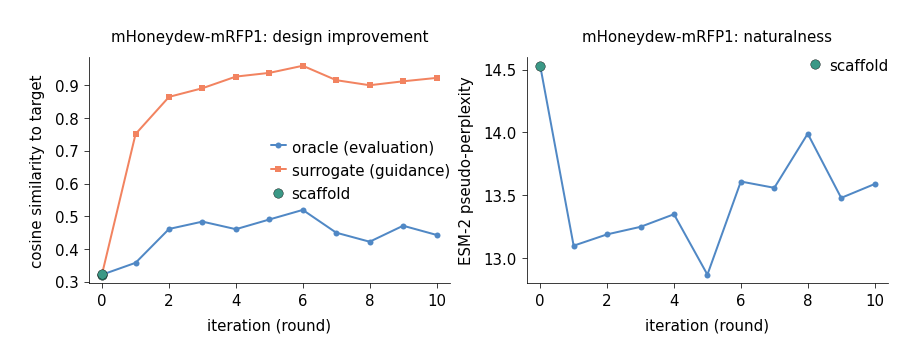

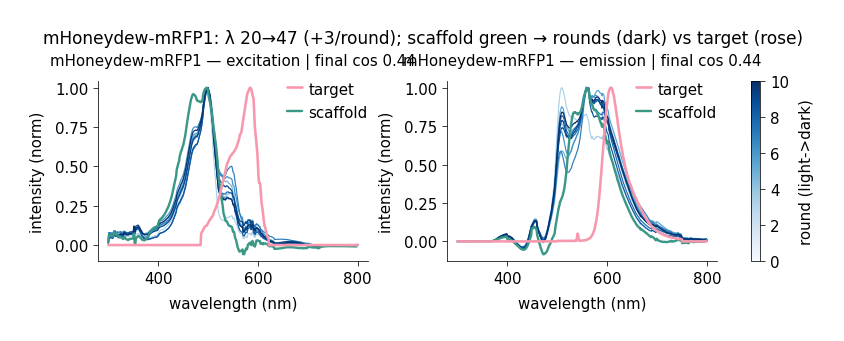

In [7]:
import glob, matplotlib as mpl
def show_cycles(files):
    SCAF=apc.seaweed
    print(f"{len(files)} example(s):", [os.path.basename(f) for f in files])
    for fn in files:
        H=sorted(list(csv.DictReader(open(fn))), key=lambda h:int(h["round"]))
        name=H[0]["example"]; maxr=max(int(h["round"]) for h in H); rr=[int(h["round"]) for h in H]
        ti=int(H[0]["target_idx"]); tgt=Y[ti]
        print(f"--- {name}: {H[0]['scaffold_name']} (em{H[0]['scaffold_em']}) -> {H[0]['target_name']} (em{H[0]['target_em']}) | seq id {float(H[0]['seq_id_scaf_target']):.0%} | cos {float(H[0]['cos']):.2f} -> {float(H[-1]['cos']):.2f}")
        if not HAVE_PLT: continue
        # (1) cosine (oracle eval + surrogate guidance) + (2) perplexity over rounds
        tt=torch.tensor(tgt,device=dev)
        orac_cos=[float(h["cos"]) for h in H]                                       # oracle = evaluation (stored in CSV)
        surr_cos=[float(cos_sim_vec(g_spectrum(h["designed_seq"]), tt)[0]) for h in H]  # surrogate = guidance (recomputed)
        fig,ax=plt.subplots(1,2,figsize=(12,4.3),constrained_layout=True)
        a=ax[0]
        a.plot(rr,orac_cos,marker="o",color=apc.aegean,label="oracle (evaluation)")
        a.plot(rr,surr_cos,marker="s",color=apc.amber,label="surrogate (guidance)")
        a.scatter([0],[orac_cos[0]],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4)
        a.scatter([0],[surr_cos[0]],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
        a.set_xlabel("iteration (round)"); a.set_ylabel("cosine similarity to target"); a.set_title(f"{name}: design improvement"); a.legend()
        a=ax[1]; a.plot(rr,[float(h["ppl"]) for h in H],marker="o",color=apc.aegean)
        a.scatter([0],[float(H[0]["ppl"])],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
        a.set_xlabel("iteration (round)"); a.set_ylabel("ESM-2 pseudo-perplexity"); a.set_title(f"{name}: naturalness"); a.legend()
        plt.show()
        # (3) excitation / emission spectra; scaffold green, rounds light->dark, target rose
        cmap=mpl.colormaps["Blues"]; cround=lambda r: cmap(0.25+0.75*r/maxr)
        halves=[("excitation",slice(0,G)),("emission",slice(G,None))]
        fig,axes=plt.subplots(1,2,figsize=(11,4.0),squeeze=False,constrained_layout=True)
        for ci,(hname,sl) in enumerate(halves):
            a=axes[0,ci]; a.plot(grid,tgt[sl],color=apc.rose,lw=2.6,zorder=4,label="target")
            for h in H:
                r=int(h["round"]); spec=oracle_spectrum(h["designed_seq"])[0].cpu().numpy()
                if r==0: a.plot(grid,spec[sl],color=SCAF,lw=2.4,zorder=3,label="scaffold")
                else:    a.plot(grid,spec[sl],color=cround(r),lw=1.2)
            a.set_title(f"{name} \u2014 {hname} | final cos {float(H[-1]['cos']):.2f}")
            a.set_xlabel("wavelength (nm)"); a.set_ylabel("intensity (norm)"); a.legend()
        sm=mpl.cm.ScalarMappable(cmap=cmap,norm=mpl.colors.Normalize(0,maxr)); sm.set_array([])
        fig.colorbar(sm,ax=axes,label="round (light->dark)",fraction=0.025)
        fig.suptitle(f"{name}: \u03bb {H[1]['lam_used']}\u2192{H[-1]['lam_used']} (+{int(H[2]['lam_used'])-int(H[1]['lam_used'])}/round); scaffold green \u2192 rounds (dark) vs target (rose)")
        plt.show()

show_cycles(sorted(glob.glob(os.path.join("fp_designs","design_*.csv"))))

## 6. Sequence alignment (per example)

Triplet alignment (**scaffold, final design, target**) for each example, cropped to the edited region, with design↔target identity in the title. Same alignment view as before.

3 per-example triplet alignments (final design)


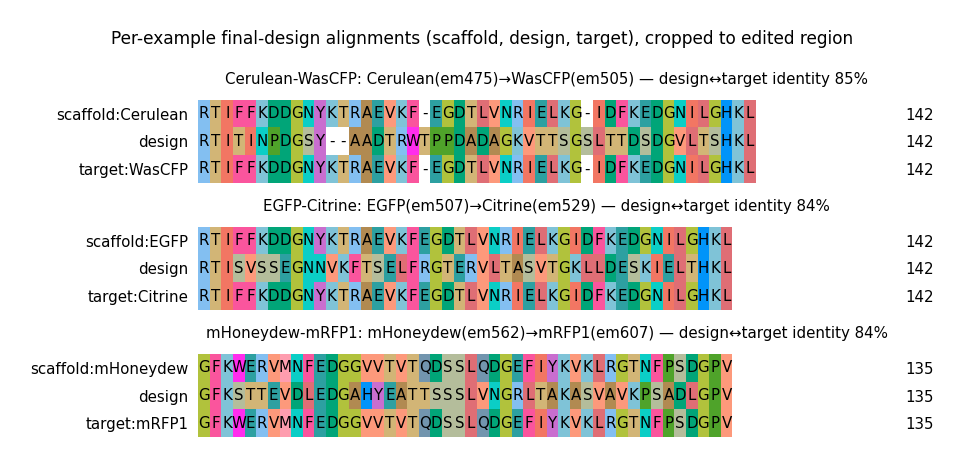

In [8]:
import glob, biotite.sequence as bseq, biotite.sequence.align as balign, biotite.sequence.graphics as bgraphics
MAT=balign.SubstitutionMatrix.std_protein_matrix(); MARGIN=3; SPL=60
def triplet_aln(scaf,des,tgt):
    raw=[scaf,des,tgt]
    aln,_,_,_=balign.align_multiple([bseq.ProteinSequence(s) for s in raw], MAT, gap_penalty=(-10,-1))
    tr=aln.trace; sym=lambda k,c:(raw[k][tr[c,k]] if tr[c,k]>=0 else "-")
    both=[c for c in range(tr.shape[0]) if tr[c,1]>=0 and tr[c,2]>=0]
    id_dt=(sum(sym(1,c)==sym(2,c) for c in both)/len(both)) if both else 0.0
    diff=[c for c in range(tr.shape[0]) if sym(0,c)!=sym(1,c)]
    lo,hi=(max(0,min(diff)-MARGIN), min(tr.shape[0],max(diff)+MARGIN+1)) if diff else (0,tr.shape[0])
    return aln[lo:hi], id_dt
def show_align(files):
    print(f"{len(files)} per-example triplet alignments (final design)")
    if HAVE_PLT and files:
        fig,axes=plt.subplots(len(files),1,figsize=(13,2*len(files))); axes=np.atleast_1d(axes)
        for r,fn in enumerate(files):
            H=sorted(list(csv.DictReader(open(fn))),key=lambda h:int(h["round"])); d=H[-1]
            labels=[f"scaffold:{d['scaffold_name']}", "design", f"target:{d['target_name']}"]
            sub,id_dt=triplet_aln(d["scaffold_seq"],d["designed_seq"],d["target_seq"])
            bgraphics.plot_alignment_type_based(axes[r], sub, labels=labels, symbols_per_line=SPL, show_numbers=True)
            axes[r].set_title(f"{d['example']}: {d['scaffold_name']}(em{d['scaffold_em']})\u2192{d['target_name']}(em{d['target_em']}) \u2014 design\u2194target identity {id_dt:.0%}")
        plt.suptitle("Per-example final-design alignments (scaffold, design, target), cropped to edited region")
        plt.tight_layout(); plt.show()

show_align(sorted(glob.glob(os.path.join("fp_designs","design_*.csv"))))

## 7. ~80% sequence identity, distinct ex_max & em_max (train/train, same protocol)

Same 10-round λ-ramp protocol (start λ=20, **+3/round**) and the same **train/train-only** pool (`Srole==train` **and** `Orole==train`), but here we pick **2 pairs at ~80% sequence identity** (in `[ID_LO, ID_HI]`, closest to `ID_TARGET`) whose **excitation and emission peaks both differ** (|Δex_max| ≥ `DEX_MIN` **and** |Δem_max| ≥ `DEM_MIN` nm) — i.e. clearly homologous but spectrally shifted in both peaks. Outputs go to `fp_designs/moderate/design_<scaffold>-<target>.csv` and are visualized with the same `show_cycles` / `show_align` helpers.

In [9]:
REGENERATE_MOD=True   # set False to reuse fp_designs/moderate/design_*.csv
ID_LO,ID_HI,ID_TARGET=0.75,0.85,0.80; DEX_MIN,DEM_MIN=15.0,15.0; KMER_LO,KMER_HI=0.40,0.92; MAXCHECK=20000; N_MOD=2
moddir=os.path.join("fp_designs","moderate"); os.makedirs(moddir, exist_ok=True)
# reuse from Section 4: LAM_START, LAM_STEP, N_ROUNDS, WINDOW, K_TOP, seq_identity, sanitize, CountVectorizer, _cossim

def find_peakshift_pairs(role,n):                                  # ~ID_TARGET identity, with distinct ex_max AND em_max peaks
    idx=np.where((Srole==role)&(Orole=="train"))[0]      # train/train only: both surrogate AND oracle trained on these
    Sk=_cossim(CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform([seqs[i] for i in idx]))
    cand=[(float(Sk[a,b]),int(idx[a]),int(idx[b])) for a in range(len(idx)) for b in range(a+1,len(idx))
          if KMER_LO<=Sk[a,b]<=KMER_HI and abs(EXM[idx[a]]-EXM[idx[b]])>=DEX_MIN and abs(EMM[idx[a]]-EMM[idx[b]])>=DEM_MIN]
    cand.sort(reverse=True)                                        # most sequence-similar first
    scored=[]
    for c,(km,i,j) in enumerate(cand):
        if c>=MAXCHECK: break
        idn=seq_identity(seqs[i],seqs[j])
        if ID_LO<=idn<=ID_HI: scored.append((abs(idn-ID_TARGET),idn,i,j))
    scored.sort()                                                 # closest to ID_TARGET first
    pairs=[]; used=set()
    for _,idn,i,j in scored:
        if i in used or j in used: continue
        si,ti=(i,j) if EMM[i]<=EMM[j] else (j,i)                  # scaffold=bluer, target=redder
        pairs.append((si,ti,idn)); used.update([i,j])
        if len(pairs)>=n: break
    return pairs

if REGENERATE_MOD:
    mpairs=find_peakshift_pairs("train", N_MOD)
    schedule=[(r, LAM_START+LAM_STEP*(r-1)) for r in range(1,N_ROUNDS+1)]
    saved=[]
    for si,ti,idn in mpairs:
        scaffold=seqs[si]; t=torch.tensor(Y[ti],device=dev); Llen=len(scaffold); mid=Llen//2
        editable=list(range(max(0,mid-WINDOW//2),min(Llen,mid+WINDOW//2)))
        name=f"{rows[si]['name']}-{rows[ti]['name']}"; dex=abs(EXM[si]-EXM[ti]); dem=abs(EMM[si]-EMM[ti])
        print(f"[{name}] ex {EXM[si]:.0f}->{EXM[ti]:.0f} (\u0394{dex:.0f}) | em {EMM[si]:.0f}->{EMM[ti]:.0f} (\u0394{dem:.0f}) | seq id {idn:.0%} | \u03bb {LAM_START}->{LAM_START+LAM_STEP*(N_ROUNDS-1)} (+{LAM_STEP}/round)")
        hist=[dict(lam_used=LAM_START,round=0,cos=float(cos_sim_vec(oracle_spectrum(scaffold),t)[0]),ppl=pseudo_perplexity(scaffold)[1],ident=1.0,seq=scaffold)]
        cur=scaffold
        for r,lam_used in schedule:
            cur,_=guided_refine(cur,t,n_sweeps=1,k=K_TOP,lam=lam_used,editable=editable,eval_fn=oracle_spectrum,verbose=False)
            cr=float(cos_sim_vec(oracle_spectrum(cur),t)[0]); pr=pseudo_perplexity(cur)[1]
            idr=sum(x==y for x,y in zip(cur,scaffold))/len(scaffold)
            hist.append(dict(lam_used=lam_used,round=r,cos=cr,ppl=pr,ident=idr,seq=cur))
            print(f"  round {r:>2} (\u03bb={lam_used}): cos {cr:.3f} | ppl {pr:.1f} | id {idr:.2f}")
        fn=os.path.join(moddir, f"design_{sanitize(name)}.csv")
        with open(fn,"w",newline="") as fh:
            w=csv.writer(fh)
            w.writerow(["example","lam_used","round","scaffold_name","scaffold_idx","scaffold_ex","scaffold_em","target_name","target_idx","target_ex","target_em","seq_id_scaf_target","d_ex","d_em","cos","ppl","ident_to_scaffold","designed_seq","scaffold_seq","target_seq"])
            for h in hist:
                w.writerow([name,h["lam_used"],h["round"],rows[si]["name"],si,f"{EXM[si]:.0f}",f"{EMM[si]:.0f}",rows[ti]["name"],ti,f"{EXM[ti]:.0f}",f"{EMM[ti]:.0f}",f"{idn:.3f}",f"{dex:.0f}",f"{dem:.0f}",f"{h['cos']:.4f}",f"{h['ppl']:.2f}",f"{h['ident']:.3f}",h["seq"],scaffold,seqs[ti]])
        saved.append(fn); print(f"  saved -> {fn}")
    print("saved examples:", [os.path.basename(s) for s in saved])
else:
    import glob; print("REGENERATE_MOD=False -> reuse:", [os.path.basename(f) for f in sorted(glob.glob(os.path.join(moddir,"design_*.csv")))])

[CyOFP1-mCardinal] ex 497->604 (Δ107) | em 589->659 (Δ70) | seq id 80% | λ 20->47 (+3/round)


  round  1 (λ=20): cos 0.403 | ppl 15.2 | id 0.88


  round  2 (λ=23): cos 0.372 | ppl 15.3 | id 0.89


  round  3 (λ=26): cos 0.371 | ppl 15.1 | id 0.88


  round  4 (λ=29): cos 0.453 | ppl 15.3 | id 0.88


...

  round  6 (λ=35): cos 0.503 | ppl 15.0 | id 0.85


  round  7 (λ=38): cos 0.509 | ppl 14.8 | id 0.85


  round  8 (λ=41): cos 0.508 | ppl 15.1 | id 0.85


  round  9 (λ=44): cos 0.521 | ppl 15.4 | id 0.85


  round 10 (λ=47): cos 0.523 | ppl 15.2 | id 0.85
  saved -> fp_designs/moderate/design_AausGFP-Topaz.csv
saved examples: ['design_CyOFP1-mCardinal.csv', 'design_AausGFP-Topaz.csv']


2 example(s): ['design_AausGFP-Topaz.csv', 'design_CyOFP1-mCardinal.csv']
--- AausGFP-Topaz: AausGFP (em503) -> Topaz (em527) | seq id 80% | cos 0.45 -> 0.52


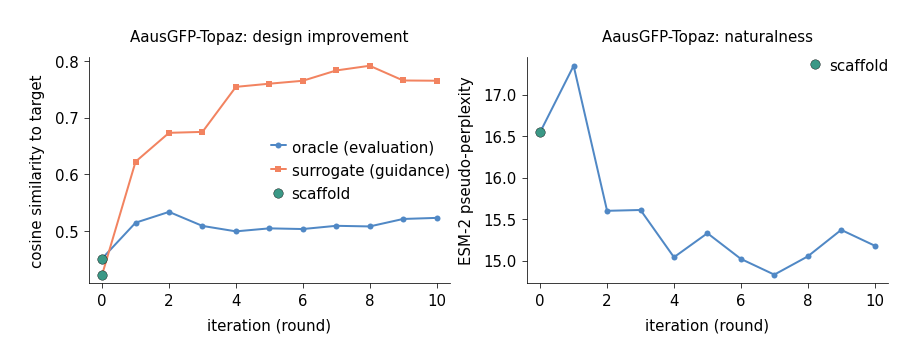

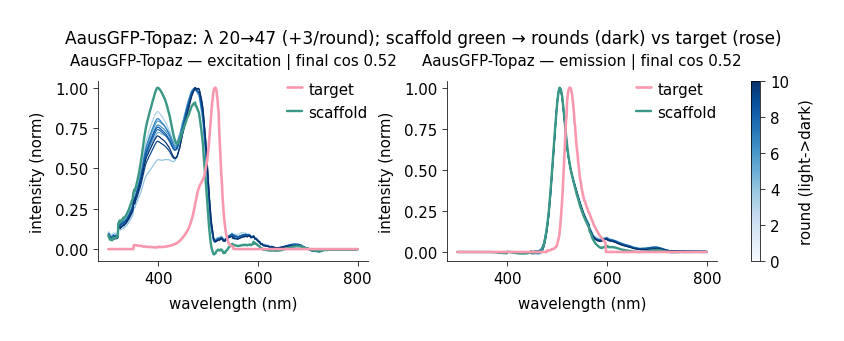

--- CyOFP1-mCardinal: CyOFP1 (em589) -> mCardinal (em659) | seq id 80% | cos 0.37 -> 0.43


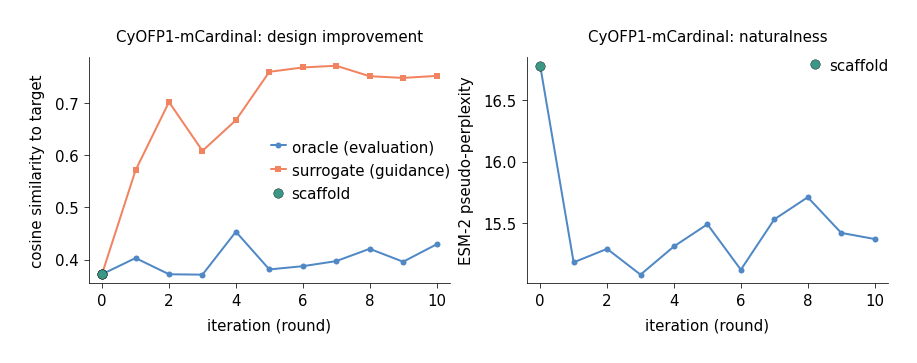

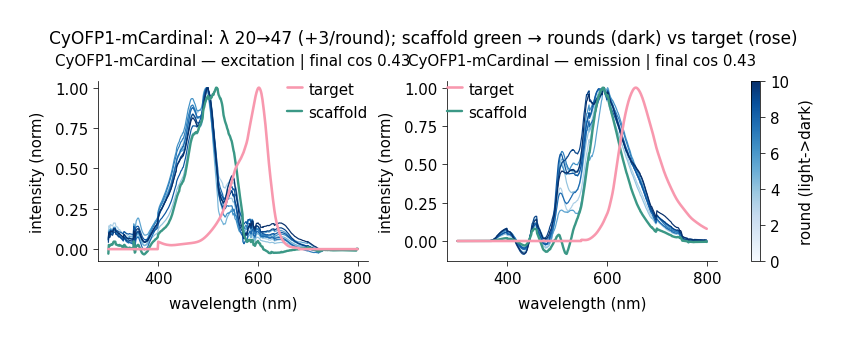

2 per-example triplet alignments (final design)


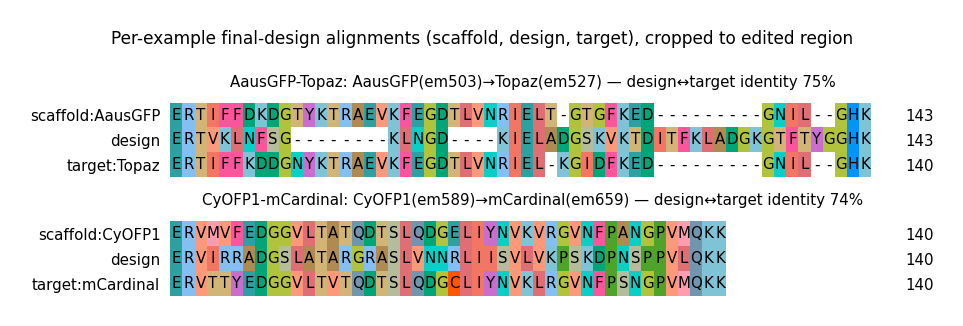

In [10]:
mod_files=sorted(glob.glob(os.path.join("fp_designs","moderate","design_*.csv")))
show_cycles(mod_files)
show_align(mod_files)

## 8. Best design across iterations (loaded from CSV)

For each example we pick the **round with the highest oracle cosine** (round ≥1; round 0 is the scaffold baseline) and show that single best design vs the target — excitation/emission spectra plus a summary table of scaffold→best cosine, the winning round/λ, naturalness (ppl) and identity to the scaffold. Nothing is regenerated; this only reads `fp_designs/design_*.csv` (very similar) and `fp_designs/moderate/design_*.csv` (~80% identity, distinct ex/em peaks).

############ very similar sequences, spectrally distinct ############


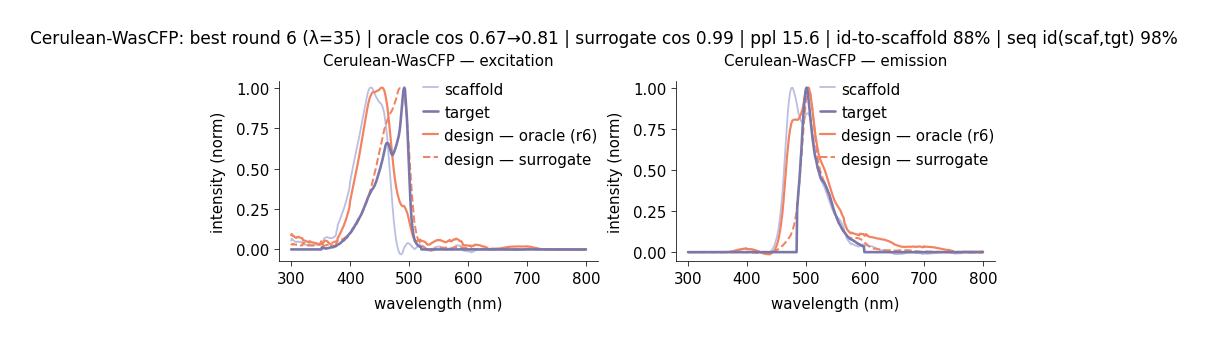

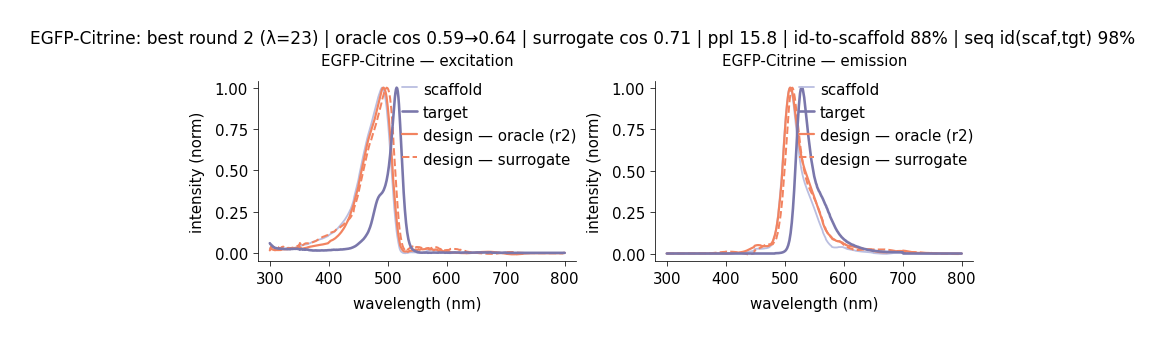

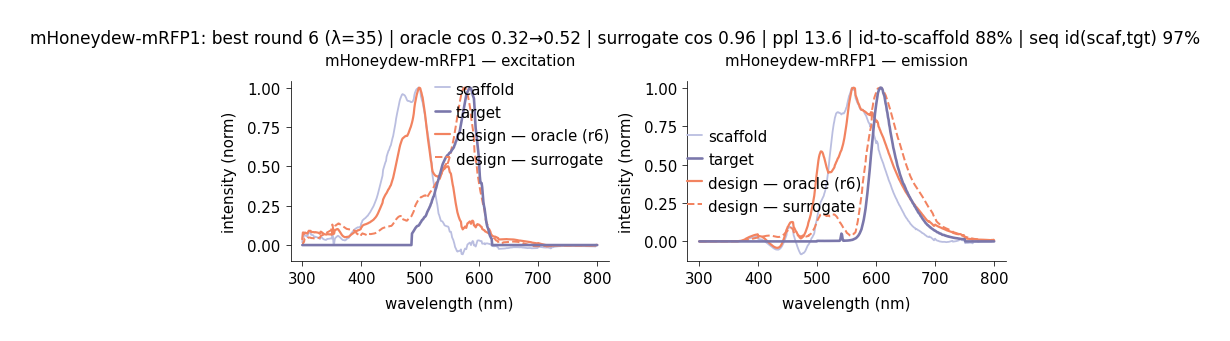


=== best design per example (very similar sequences, distinct spectra) ===
example                    seq id scaf cos best r   λ orac cos surr cos    Δcos   ppl  id->scaf
Cerulean-WasCFP              98%    0.665      6  35    0.808    0.987  +0.143  15.6      88%
EGFP-Citrine                 98%    0.586      2  23    0.643    0.709  +0.057  15.8      88%
mHoneydew-mRFP1              97%    0.321      6  35    0.519    0.960  +0.198  13.6      88%

############ ~80% identity, distinct ex_max & em_max ############


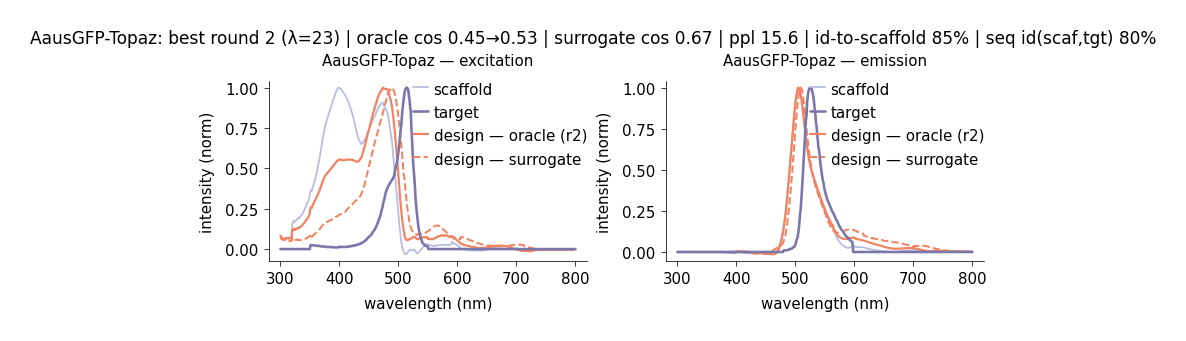

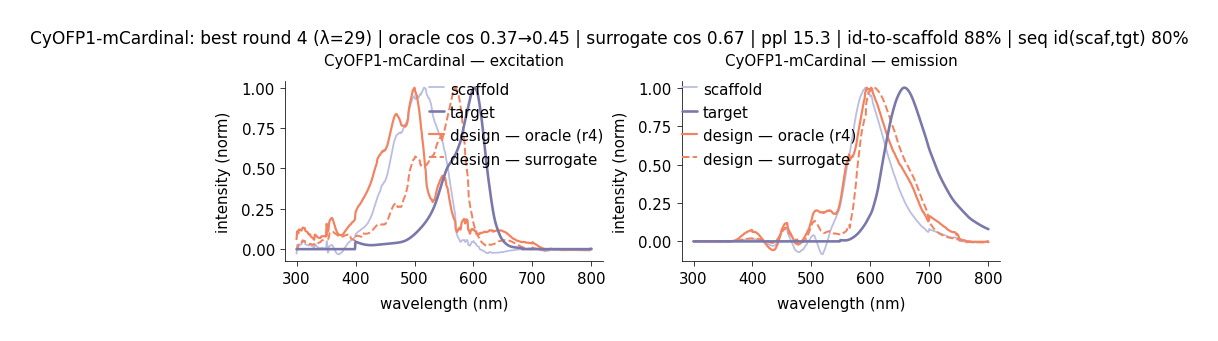


=== best design per example (~80% identity, distinct ex/em peaks) ===
example                    seq id scaf cos best r   λ orac cos surr cos    Δcos   ppl  id->scaf
AausGFP-Topaz                80%    0.451      2  23    0.534    0.673  +0.082  15.6      85%
CyOFP1-mCardinal             80%    0.372      4  29    0.453    0.667  +0.081  15.3      88%


In [11]:
import glob, matplotlib as mpl
def show_best(files, group):
    SCAF=apc.seaweed; BEST=apc.aegean
    rowsum=[]
    for fn in files:
        H=sorted(list(csv.DictReader(open(fn))), key=lambda h:int(h["round"]))
        scaf=H[0]; gen=[h for h in H if int(h["round"])>=1]
        best=max(gen, key=lambda h:float(h["cos"]))                       # best design = max oracle cosine across iterations
        name=best["example"]; ti=int(best["target_idx"]); tgt=Y[ti]
        tt=torch.tensor(tgt,device=dev)
        b_orac=oracle_spectrum(best["designed_seq"])[0]; b_surr=g_spectrum(best["designed_seq"])[0]
        b_surr_cos=float(cos_sim_vec(b_surr.unsqueeze(0),tt)[0])
        rowsum.append((name,float(scaf["seq_id_scaf_target"]),float(scaf["cos"]),int(best["round"]),
                       int(float(best["lam_used"])),float(best["cos"]),b_surr_cos,float(best["ppl"]),float(best["ident_to_scaffold"])))
        if not HAVE_PLT: continue
        bspec=b_orac.cpu().numpy(); bspec_s=b_surr.cpu().numpy()
        sspec=oracle_spectrum(scaf["designed_seq"])[0].cpu().numpy()
        fig,axes=plt.subplots(1,2,figsize=(11,4.0),squeeze=False,constrained_layout=True)
        for ci,(hname,sl) in enumerate([("excitation",slice(0,G)),("emission",slice(G,None))]):
            a=axes[0,ci]
            a.plot(grid,sspec[sl],color=apc.wish,lw=1.8,zorder=2,label="scaffold")
            a.plot(grid,tgt[sl],color=apc.aster,lw=2.6,zorder=4,label="target")
            a.plot(grid,bspec[sl],color=apc.amber,lw=2.2,zorder=3,label=f"design — oracle (r{best['round']})")
            a.plot(grid,bspec_s[sl],color=apc.amber,lw=2.0,ls="--",zorder=3,label="design — surrogate")
            a.set_xlabel("wavelength (nm)"); a.set_ylabel("intensity (norm)")
            a.set_title(f"{name} \u2014 {hname}"); a.legend()
        fig.suptitle(f"{name}: best round {best['round']} (\u03bb={int(float(best['lam_used']))}) | "
                     f"oracle cos {float(scaf['cos']):.2f}\u2192{float(best['cos']):.2f} | surrogate cos {b_surr_cos:.2f} | ppl {float(best['ppl']):.1f} | "
                     f"id-to-scaffold {float(best['ident_to_scaffold']):.0%} | seq id(scaf,tgt) {float(scaf['seq_id_scaf_target']):.0%}")
        plt.show()
    print(f"\n=== best design per example ({group}) ===")
    print(f"{'example':<26}{'seq id':>7}{'scaf cos':>9}{'best r':>7}{'λ':>4}{'orac cos':>9}{'surr cos':>9}{'Δcos':>8}{'ppl':>6}{'id->scaf':>10}")
    for name,sid,scos,br,lam,bcos,bscos,ppl,idsc in rowsum:
        print(f"{name:<26}{sid:>6.0%}{scos:>9.3f}{br:>7d}{lam:>4d}{bcos:>9.3f}{bscos:>9.3f}{bcos-scos:>+8.3f}{ppl:>6.1f}{idsc:>9.0%}")
    return rowsum

hi_files=sorted(glob.glob(os.path.join("fp_designs","design_*.csv")))
mod_files=sorted(glob.glob(os.path.join("fp_designs","moderate","design_*.csv")))
print("############ very similar sequences, spectrally distinct ############")
_=show_best(hi_files,"very similar sequences, distinct spectra")
print("\n############ ~80% identity, distinct ex_max & em_max ############")
_=show_best(mod_files,"~80% identity, distinct ex/em peaks")

## Notes

- **ID-only** redesign: three sequence-similar / spectrally-distinct in-sample pairs (incl. **P4→EGFP**); OOD removed for now.
- **Generation logic unchanged**; only the schedule (start λ=20, **+3/round × 10 rounds**) and per-example CSV output (`fp_designs/design_<scaffold>-<target>.csv`) differ.
- Surrogate and oracle are both `cnn-max` (cosine-trained, peak-normalized spectra); guidance and judgment use per-half cosine similarity.
- Set `REGENERATE=False` to reuse saved `design_*.csv` for the visualizations.